This notebook explores historical stock market data to build a machine learning model capable of predicting short-term stock price movement. Using a Kaggle dataset containing daily trading information (open, high, low, and closing prices), the data was first cleaned and organized chronologically to ensure proper time-series analysis.

Feature engineering techniques were applied to create additional indicators that capture market trends, including moving averages and daily returns. These engineered features help the model detect patterns in price behavior over time.

A Random Forest classification model was then trained to predict whether the stock price will increase or decrease on the following trading day. The dataset was split into training and testing sets while preserving the time order of observations to avoid data leakage.

Model performance was evaluated using accuracy metrics, confusion matrices, and classification reports. Visualizations were also created to compare predicted movements with actual price changes and to analyze feature importance.

Overall, this notebook demonstrates a complete machine learning workflow for financial time-series data, including data exploration, feature engineering, model training, and evaluation of predictive performance.

In [1]:
#Richelle Williams
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Download latest version
path = kagglehub.dataset_download("satyajeetbedi/stock-price-dataset")

print("Path to dataset files:", path)



Path to dataset files: /kaggle/input/datasets/satyajeetbedi/stock-price-dataset


In [5]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/satyajeetbedi/stock-price-dataset/data (2).csv


In [6]:
df = pd.read_csv("/kaggle/input/datasets/satyajeetbedi/stock-price-dataset/data (2).csv")
df.head()

,mic,symbol,isin,date,open_value,high_value,low_value,last_value,change_prev_close_percentage,turnover
0,XZAG,CBX,HRZB00ICBEX6,2015-12-30,1689.22,1689.71,1673.62,1689.63,-0.02,2017520.82
1,XZAG,CBX,HRZB00ICBEX6,2015-12-29,1675.79,1691.02,1673.37,1689.94,0.84,1094356.06
2,XZAG,CBX,HRZB00ICBEX6,2015-12-28,1655.92,1677.17,1652.76,1675.88,1.21,1125687.29
3,XZAG,CBX,HRZB00ICBEX6,2015-12-23,1647.66,1655.77,1641.41,1655.77,0.49,592284.75
4,XZAG,CBX,HRZB00ICBEX6,2015-12-22,1655.71,1655.71,1642.60,1647.67,-0.55,2714509.05


In [7]:
df = df.sort_values("date")

df = df[[
    "date",
    "open_value",
    "high_value",
    "low_value",
    "last_value"
]]

df.head()

,date,open_value,high_value,low_value,last_value
1497,2010-01-04,2001.34,2025.90,1979.85,2023.36
1496,2010-01-05,2024.82,2071.80,2023.17,2050.69
1495,2010-01-07,2058.04,2075.66,2046.12,2059.90
1494,2010-01-08,2071.17,2074.79,2062.27,2074.79
1493,2010-01-11,2080.33,2115.98,2080.32,2112.17


In [8]:
df["Target"] = (df["last_value"].shift(-1) > df["last_value"]).astype(int)

df.head()

,date,open_value,high_value,low_value,last_value,Target
1497,2010-01-04,2001.34,2025.90,1979.85,2023.36,1
1496,2010-01-05,2024.82,2071.80,2023.17,2050.69,1
1495,2010-01-07,2058.04,2075.66,2046.12,2059.90,1
1494,2010-01-08,2071.17,2074.79,2062.27,2074.79,1
1493,2010-01-11,2080.33,2115.98,2080.32,2112.17,0


In [19]:
df["MA10"] = df["last_value"].rolling(10).mean()
df["MA50"] = df["last_value"].rolling(50).mean()

df["Return"] = df["last_value"].pct_change()

df.dropna(inplace=True)

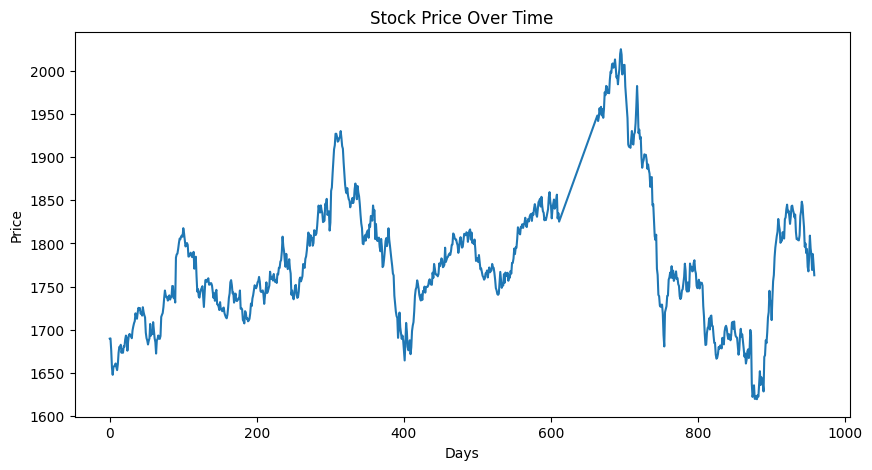

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df["last_value"])
plt.title("Stock Price Over Time")
plt.xlabel("Days")
plt.ylabel("Price")
plt.show()

In [21]:
from sklearn.model_selection import train_test_split

features = [
    "open_value",
    "high_value",
    "low_value",
    "last_value",
    "MA10",
    "MA50",
    "Return"
]

X = df[features]
y = df["Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [22]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=200)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

In [23]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.5164835164835165


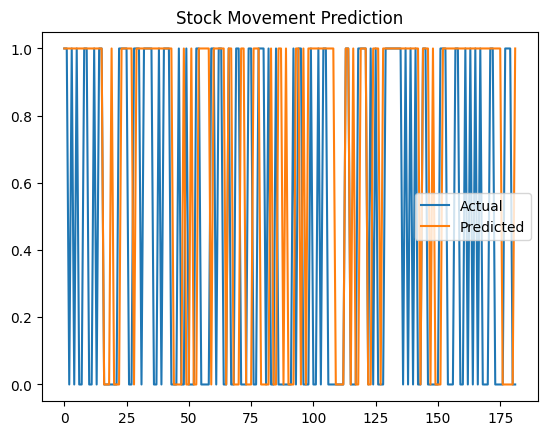

In [24]:
plt.plot(y_test.values, label="Actual")
plt.plot(predictions, label="Predicted")

plt.legend()
plt.title("Stock Movement Prediction")

plt.show()

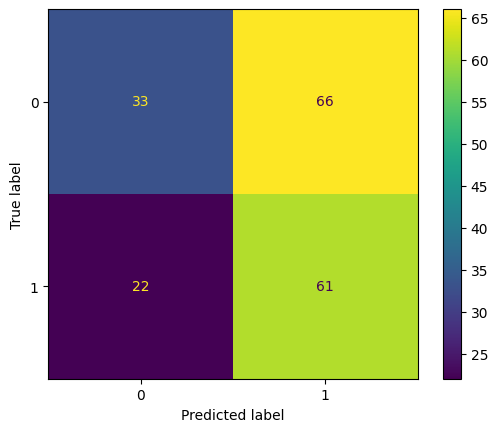

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, predictions)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

In [27]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.60      0.33      0.43        99
           1       0.48      0.73      0.58        83

    accuracy                           0.52       182
   macro avg       0.54      0.53      0.50       182
weighted avg       0.55      0.52      0.50       182



In [29]:
import pandas as pd

importance = model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
}).sort_values("Importance", ascending=False)

print(feature_importance)

      Feature  Importance
5        MA50    0.154193
6      Return    0.150837
0  open_value    0.141922
1  high_value    0.141803
4        MA10    0.140368
3  last_value    0.135521
2   low_value    0.135357


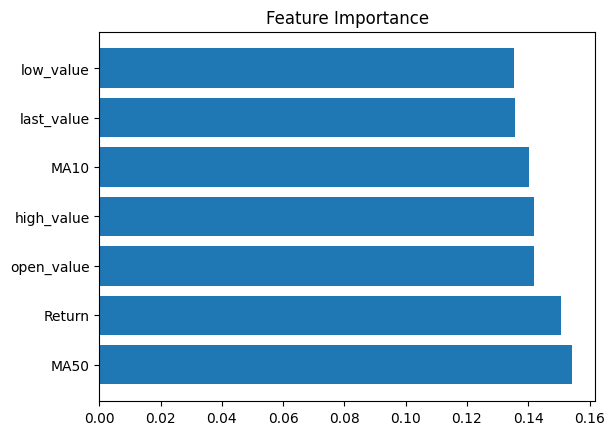

In [30]:
import matplotlib.pyplot as plt

plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.title("Feature Importance")
plt.show()